In [2]:
import reconstruction as rc
import geometry as geo
import util as util
import CTfiltre as CTfilter
import importlib

import numpy as np
import time
import math as mt
import cmath as cmt
import matplotlib.pyplot as plt
import scipy.interpolate as interp
import scipy as sc

--- 0.0 seconds ---


#### Question 1 ####

Grâce à la base de données XCOM du NIST (http://physics.nist.gov/PhysRefData/Xcom/html/xcom1.html), le l'atténuation total pour 60 keV dans l'eau est de 0.2059 $cm^2/g$ ce qui donne pour densité de 1 g / $cm^3$ un $\mu$ de 0.2059/cm.

In [9]:
import numpy as np

mu = 0.2059 #/cm
I_0 = 60 #keV
x_5 = 5 #cm
x_20 = 20 #cm

def ration_output_input_intensity(x):
    return np.e**(-mu*x)

print(f'Fraction signal après 5 cm: {ration_output_input_intensity(x_5):.5f}')
print(f'Fraction signal après 20 cm: {ration_output_input_intensity(x_20):.5f}')

Fraction signal après 5 cm: 0.35719
Fraction signal après 20 cm: 0.01628


#### Question 2 ####

#### Question 3 ####

#### Question 4 ####

#### Question 5 - Amélioration de la qualitée de l'image

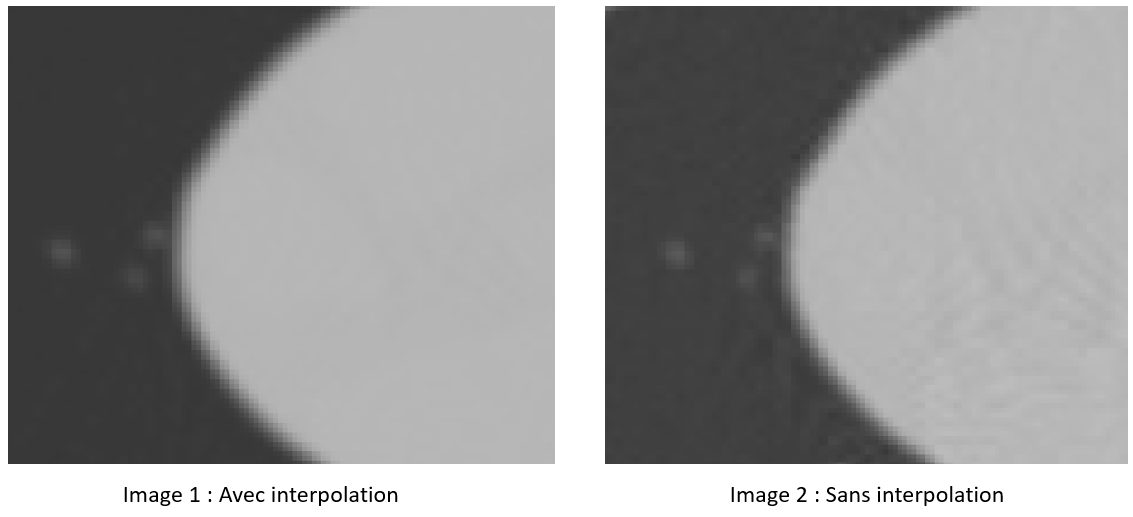

En interpolant plutôt qu’en utilisant la méthode du plus proche voisin, on observe que l’image obtenue est plus uniforme. Le temps de calcul avec interpolation est de 1.21 secondes, contre 1.52 secondes pour la méthode sans interpolation. Cette différence de temps est surprenante, étant donné que la méthode avec interpolation exécute davantage de lignes de code que celle sans interpolation.

Face à ce résultat inattendu, des tests supplémentaires ont été effectués. Puisque la méthode utilisant l’interpolation ne faisait pas appel à la fonction "round", une première hypothèse a été formulée : cette fonction pourrait être responsable d’un temps d’exécution plus élevé. Elle a donc été remplacée par une fonction plus simple du module math, soit "math.ceil," qui arrondit à l’entier supérieur. En utilisant cette fonction, le temps d’exécution est passé à seulement 0.86 secondes (bien que l'image soit différent). Cela confirme que la fonction "math.ceil" est plus rapide que la fonction round.

Un dernier test a été réalisé afin d’obtenir un résultat identique à celui produit par la fonction "round", mais en utilisant plutôt les fonctions "math.floor" et "math.ceil". Cette approche ajoute plusieurs lignes de code, mais le temps de calcul obtenu est de 0.74 secondes, ce qui est plus rapide que celui de la méthode avec interpolation.

#### Question 6 ####

In [3]:
importlib.reload(rc)
importlib.reload(geo)

def reconFourierSlice():
    [nbprj, angles, sinogram] = rc.readInput()

    N = geo.nbpix
    M = geo.nbvox

    #conteneur pour la FFT du sinogramme
    SINOGRAM = np.zeros((M, M), 'complex')
    print(SINOGRAM.shape)
    
    sinoX = np.fft.fftshift(np.fft.fftfreq(N))*N
    counts = np.zeros_like(SINOGRAM, dtype=float)

    for a, th in enumerate(angles):
        sinoTF = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(sinogram[a,:])))
        
        for b, w in enumerate(sinoX):
            kx = round((M)//2 + w * np.cos(th))
            ky = round((M)//2 + w * np.sin(th))

            if 0 <= ky < M and 0 <= kx < M:
                SINOGRAM[ky, kx] += sinoTF[b]
                counts[ky, kx] += 1


    #Normalisation pour éviter l'accumulation au centre
    SINOGRAM[counts > 0] /= counts[counts > 0]

    #Retour dans l'espace spatial
    image = SINOGRAM
    image = np.fft.ifftshift(np.fft.ifft2(image))
    image = np.fliplr(np.abs(image)) 

    util.saveImage(image, "fft_reconstructed")


--- 0.0 seconds ---


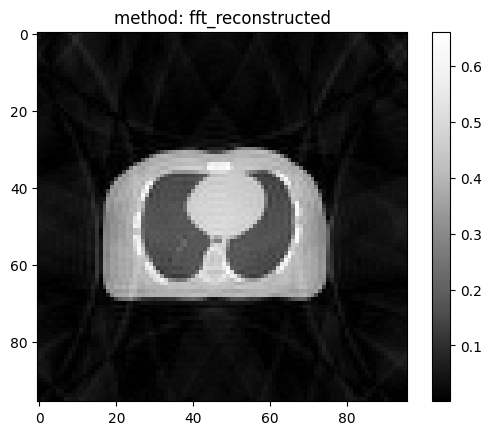

#### Question 7 ####

On voit que la recontstruction a beacuoup d'artéfact de forme circulaire. De plus, étant donné que celle-ci a été fait avec une grille de 96x96 pixels, la résolution de l'image est très faible et on perçoit mal les détails.

#### Question 8 ####

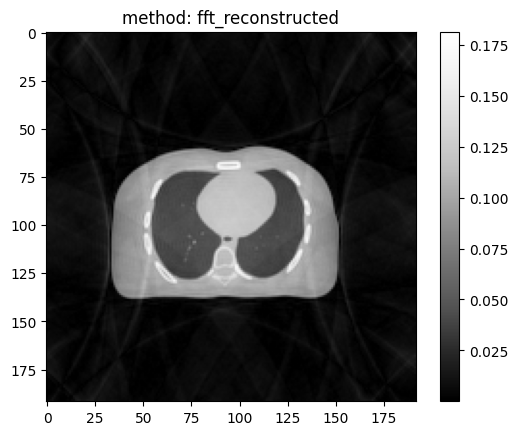 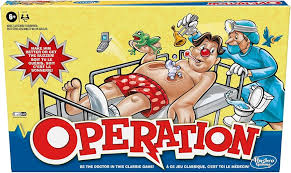

On voit que la résolution de l'image s'est beaucoup amélioré et que les détails sont bien visible. En tant que professionnel du jeux opérations, nous pouvons afirmer sans aucune gêne que cette image est acceptable pour un diagnostique médical. Nous pouvons même affirmer que la personne a un cancer du poumon ainsi qu'une fracture de la colonne vertébrale à la vertèbre T4. Nous recommandons donc des Tylenols, des Advils et une caisse de bière pour le moral.

#### Question 9 ####

#### Question 10 ####